# Auerbach–Kotlikoff Overlapping-Generations Model

## Model Overview

A deterministic OLG model with $T=40$ working periods and $T_R=20$ retirement periods.

**Household preferences** over consumption $c$ and labour $n$:
$$u(c,n) = \frac{\left[(c+\psi_0)(1-n)^\gamma\right]^{1-\sigma}-1}{1-\sigma}$$

**Budget constraints:**
- Worker:  $c^s + a^{s+1} = (1+r)a^s + (1-\tau)w n^s$
- Retiree: $c^s + a^{s+1} = (1+r)a^s + p$

**Optimality conditions — workers:**
$$\frac{u_c(c^s,n^s)}{\beta} = (1+r)\,u_c(c^{s+1},n^{s+1}) \quad \text{(Euler)} \qquad (1-\tau)w\,u_c = u_n \quad \text{(intratemporal)}$$

**Optimality condition — retirees:**
$$\frac{u_c(c^s,0)}{\beta} = (1+r)\,u_c(c^{s+1},0)$$

**Firm (Cobb–Douglas):** $Y = K^\alpha L^{1-\alpha}$
$$r = \alpha K^{\alpha-1}L^{1-\alpha} - \delta \qquad w = (1-\alpha)K^\alpha L^{-\alpha}$$

**Pension (PAYG, budget-balanced):**
$$p = \mathrm{rep}\cdot(1-\tau)\,w\,L\cdot\tfrac{3}{2} \qquad \tau = \frac{\mathrm{rep}}{2+\mathrm{rep}}$$

**Algorithm:** shooting/secant on terminal wealth $a^{T+T_R}$, nested inside a fixed-point iteration on $(K,L)$.

**Sections 12–14 add a uniqueness diagnostic** that probes how the solver behaves with respect to initial conditions and visualises the fixed-point map.

## 1. Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import os, io, contextlib, time

%matplotlib inline

In [4]:
# Output folder for saved plots
output_dir = r"C:\Users\russale86005\Dropbox\TEACHING\Advanced Macro Fiscal Policies\New_Course_OLG_2026\Lectures\02_pensions_and_public_debt\code\Python\Output"
if not os.path.exists(os.path.dirname(output_dir)):
    output_dir = "."
os.makedirs(output_dir, exist_ok=True)

## 2. Calibration

All parameters live in a single dict `par` — change one number here and the entire model updates.

In [8]:
# ---------- Preferences ----------
beta0 = 0.96     # subjective discount factor
sigma = 2.0      # CRRA coefficient
gam   = 2.0      # leisure weight in utility
psi0  = 0.001    # utility shifter (avoids corner solutions)

# ---------- Technology ----------
alpha = 0.36     # capital share (Cobb-Douglas)
delta = 0.10     # depreciation rate

# ---------- Demographics & pension ----------
t   = 40
tr  = 20
rep = 0.30                  # replacement ratio
tau = rep / (2.0 + rep)     # tax rate implied by pension budget balance

# ---------- Solver settings ----------
phi  = 0.80    # dampening weight for aggregate updating
tol  = 0.001   # outer-loop convergence tolerance
tolk = 0.001   # inner-loop convergence tolerance on a^1
nq1  = 30      # max inner iterations (shooting)
nq   = 30      # max outer iterations (K, L)

par = dict(
    psi0=psi0, gam=gam, sigma=sigma,
    alpha=alpha, beta0=beta0, delta=delta,
    tr=tr, t=t, tau=tau, rep=rep
)

print(f'Tax rate tau = {tau:.4f}  (rep = {rep})')
print(f'Total cohorts: {t+tr}  ({t} working + {tr} retired)')

Tax rate tau = 0.1304  (rep = 0.3)
Total cohorts: 60  (40 working + 20 retired)


## 3. Utility and Firm Functions

### 3a. Preferences
$$u_c = (c+\psi_0)^{-\sigma}(1-n)^{\gamma(1-\sigma)} \qquad u_n = \gamma(c+\psi_0)^{1-\sigma}(1-n)^{\gamma(1-\sigma)-1}$$

In [11]:
def uc(c, l, par):
    """Marginal utility of consumption."""
    psi0, gam, sigma = par['psi0'], par['gam'], par['sigma']
    return (c + psi0)**(-sigma) * (1.0 - l)**(gam * (1.0 - sigma))

def un(c, l, par):
    """Marginal utility of leisure."""
    psi0, gam, sigma = par['psi0'], par['gam'], par['sigma']
    return gam * (c + psi0)**(1.0 - sigma) * (1.0 - l)**(gam * (1.0 - sigma) - 1.0)

### 3b. Firm
$$r = \alpha K^{\alpha-1}L^{1-\alpha}-\delta \qquad w=(1-\alpha)K^\alpha L^{-\alpha}$$

In [14]:
def interest(k, l, par):
    """Equilibrium interest rate."""
    return par['alpha'] * k**(par['alpha']-1.0) * l**(1.0-par['alpha']) - par['delta']

def wage(k, l, par):
    """Equilibrium wage."""
    return (1.0 - par['alpha']) * k**par['alpha'] * l**(-par['alpha'])

## 4. Euler-Equation Residuals

**Retired agent** — find $a^{T+i}$ given $a^{T+i+1}$:
$$\frac{u_c(c^{T+i},0)}{\beta} - (1+r)\,u_c(c^{T+i+1},0) = 0 \qquad c^{T+i}=(1+r)a^{T+i}+p-a^{T+i+1}$$

**Working agent** — find $(a^i, n^i)$ given $a^{i+1}$:
$$\frac{u_c(c^i,n^i)}{\beta} - (1+r)\,u_c(c^{i+1},n^{i+1}) = 0 \qquad (1-\tau)w\,u_c(c^i,n^i) - u_n(c^i,n^i) = 0$$

In [17]:
def euler_retired(x, par):
    """Euler residual for retired agent at index i within retirement."""
    aopt          = par['aopt']
    i, t, tr      = par['i'], par['t'], par['tr']
    r, pen, beta0 = par['r'], par['pen'], par['beta0']

    k0 = x[0]
    k1 = aopt[i + t]
    k2 = 0.0 if i == tr-1 else aopt[i+t+1]

    c0 = max((1.0+r)*k0 + pen - k1, 1e-10)
    c1 = max((1.0+r)*k1 + pen - k2, 1e-10)
    return uc(c0, 0.0, par) / beta0 - uc(c1, 0.0, par) * (1.0+r)


def euler_young(x, par):
    """Two-equation system for working agent at index i: Euler + intratemporal."""
    k0, n0         = x[0], x[1]
    aopt, nopt     = par['aopt'], par['nopt']
    i, t           = par['i'], par['t']
    r, pen, beta0  = par['r'], par['pen'], par['beta0']
    tau, w         = par['tau'], par['w']

    k1 = aopt[i]
    k2 = aopt[i+1]

    if i == t:
        n1 = 0.0
        c1 = (1.0+r)*k1 + pen - k2
    else:
        n1 = nopt[i]
        c1 = (1.0+r)*k1 + (1.0-tau)*w*n1 - k2

    c0 = max((1.0+r)*k0 + (1.0-tau)*w*n0 - k1, 1e-10)
    c1 = max(c1, 1e-10)

    rf1 = uc(c0,n0,par)/beta0 - uc(c1,n1,par)*(1.0+r)
    rf2 = (1.0-tau)*w*uc(c0,n0,par) - un(c0,n0,par)
    return np.array([rf1, rf2])

## 5. Backward Induction

Given prices $(w,r,p)$ and terminal wealth $a^{T+T_R}$, solve one cohort at a time from oldest to youngest.

In [20]:
def backward_induction(aopt, copt, nopt, par):
    """Solve the household problem backward from age T+TR to age 1."""
    t, tr     = par['t'], par['tr']
    r, pen, w = par['r'], par['pen'], par['w']
    tau       = par['tau']

    # Retired cohorts
    for i in range(tr-1, 0, -1):
        par['i'] = i
        x0 = np.array([aopt[i+t]])
        a0, _, ier, _ = fsolve(euler_retired, x0, args=(par,), full_output=True)
        if ier == 1:
            aopt[i+t-1] = a0[0]
        copt[i+t-1] = max(pen + (1.0+r)*aopt[i+t-1] - aopt[i+t], 1e-10)
        par['aopt'] = aopt

    # Working cohorts
    for i in range(t, 0, -1):
        par['i'] = i
        x0 = np.array([aopt[i], nopt[i-1]])
        xf, _, ier, _ = fsolve(euler_young, x0, args=(par,), full_output=True)
        if ier == 1:
            aopt[i-1] = xf[0]
            nopt[i-1] = xf[1]
        copt[i-1] = max(nopt[i-1]*w*(1.0-tau) + (1.0+r)*aopt[i-1] - aopt[i], 1e-10)
        par['aopt'] = aopt
        par['nopt'] = nopt

    return aopt, copt, nopt

## 6. Inner Loop: Shooting on Terminal Wealth $a^{T+T_R}$

Two-point boundary value problem solved by the **secant method** on terminal wealth:
$$k60_{\text{new}} = k60_{q_1-1} - \frac{k60_{q_1-1}-k60_{q_1-2}}{a^1_{q_1-1}-a^1_{q_1-2}}\cdot a^1_{q_1-1}$$

The original notebook uses the loop condition `(q1 < nq1) or ((q1 < 5) or abs(aopt[0]) > tolk)`, which always runs at least `nq1` iterations. The version below uses the *and*-form (max `nq1` with early stopping) so that the multi-start sweep in Section 12 is fast. For the baseline solve in Section 8 the two converge to the same solution.

In [23]:
def shooting_loop(aopt, copt, nopt, par, nq1, tolk, k60_init, verbose=False):
    """Find terminal wealth a^{T+TR} such that implied a^1 = 0."""
    t, tr = par['t'], par['tr']
    r, pen = par['r'], par['pen']
    k60q, k1q = [], []
    q1 = 0

    while q1 < nq1 and (q1 < 5 or abs(aopt[0]) > tolk):
        q1 += 1
        if q1 == 1:
            k60 = k60_init
        elif q1 == 2:
            k60 = k60_init + 0.05
        else:
            dk60 = k60q[-1] - k60q[-2]
            dk1  = k1q[-1]  - k1q[-2]
            if abs(dk1) < 1e-14:
                k60 = k60q[-1] + 0.01
            else:
                k60 = k60q[-1] - dk60/dk1 * k1q[-1]

        aopt[t+tr-1] = k60
        copt[t+tr-1] = pen + (1.0+r)*k60
        k60q.append(k60)
        par['aopt'] = aopt

        aopt, copt, nopt = backward_induction(aopt, copt, nopt, par)
        k1q.append(aopt[0])

        if verbose:
            print(f'    q1={q1:2d}   a^1={aopt[0]:+.6f}   k60={k60:.6f}')

    return aopt, copt, nopt, k60

## 7. Outer Loop: Fixed-Point Iteration on $(K, L)$

Prices are computed from current $(K,L)$, the household problem is solved, and aggregates are updated with a dampened rule:
$$K' = \phi K + (1-\phi)\,\bar{a} \qquad L' = \phi L + (1-\phi)\,\bar{n}\cdot\tfrac{2}{3}$$
Convergence when $|K'-K|/K < \texttt{tol}$. Initial guesses $(K_0, L_0)$ are accepted as optional arguments — used by Section 12.

In [26]:
def solve_steady_state(par, nq, nq1, tol, tolk, phi, K0=None, L0=None, verbose=True):
    """Outer fixed-point loop on aggregate capital K and employment L."""
    t, tr, alpha, delta = par['t'], par['tr'], par['alpha'], par['delta']
    rep, tau = par['rep'], par['tau']

    nbar = 0.20 if L0 is None else L0
    if K0 is None:
        r0 = 0.045
        kbar = (alpha/(r0+delta))**(1.0/(1.0-alpha)) * nbar
    else:
        kbar = K0

    aopt = np.zeros(t+tr)
    copt = np.zeros(t+tr)
    nopt = 0.30 * np.ones(t)
    par['nopt'] = nopt

    history = {'q': [], 'kbar': [], 'nbar': [], 'krit': []}

    k60_init = 0.10
    q, krit = 0, 1.0 + tol

    while q < nq and krit > tol:
        q += 1
        if verbose:
            print(f'\nOuter q={q:2d}  krit={krit:.4e}  K={kbar:.5f}  N={nbar:.5f}')

        w   = wage(kbar, nbar, par)
        r   = interest(kbar, nbar, par)
        pen = rep * (1.0-tau) * w * nbar * 1.5
        par.update({'w': w, 'r': r, 'pen': pen})

        aopt, copt, nopt, k60_init = shooting_loop(
            aopt, copt, nopt, par, nq1, tolk, k60_init, verbose=verbose
        )

        knew = np.mean(aopt)
        nnew = np.mean(nopt) * 2.0/3.0
        krit = abs((kbar - knew) / kbar)
        kbar = phi*kbar + (1.0-phi)*knew
        nbar = phi*nbar + (1.0-phi)*nnew

        history['q'].append(q); history['kbar'].append(kbar)
        history['nbar'].append(nbar); history['krit'].append(krit)

    if verbose:
        print('\n=== CONVERGED ===')
    return dict(kbar=kbar, nbar=nbar, aopt=aopt, copt=copt, nopt=nopt, history=history)

## 8. Run the Model

In [29]:
ss = solve_steady_state(par, nq=nq, nq1=nq1, tol=tol, tolk=tolk, phi=phi, verbose=False)

## 9. Steady-State Results

In [32]:
kbar = ss['kbar'];  nbar = ss['nbar']
aopt = ss['aopt'];  copt = ss['copt'];  nopt = ss['nopt']

print('=== STEADY-STATE SOLUTION ===')
print(f'  Aggregate capital  K  = {kbar:.6f}')
print(f'  Aggregate labour   L  = {nbar:.6f}')
print(f'  Equilibrium wage   w  = {wage(kbar, nbar, par):.6f}')
print(f'  Equilibrium rate   r  = {interest(kbar, nbar, par):.6f}')
print(f'  Initial wealth   a^1  = {aopt[0]:.6f}   (target: 0)')

=== STEADY-STATE SOLUTION ===
  Aggregate capital  K  = 0.871375
  Aggregate labour   L  = 0.222620
  Equilibrium wage   w  = 1.045998
  Equilibrium rate   r  = 0.050318
  Initial wealth   a^1  = 0.000000   (target: 0)


## 10. Convergence Diagnostics

The criterion $|K'-K|/K$ should fall geometrically toward zero. A flat or oscillating path signals that `phi` needs to be increased toward 0.9 to slow updating and stabilise the iteration.

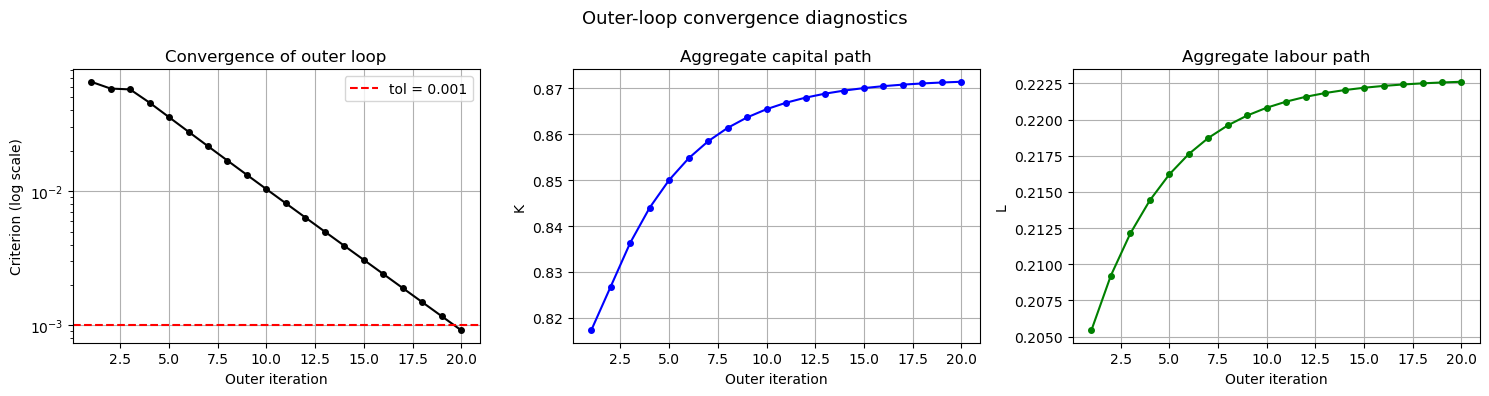

In [35]:
hist = ss['history']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(hist['q'], hist['krit'], 'k-o', markersize=4)
axes[0].axhline(tol, color='r', linestyle='--', label=f'tol = {tol}')
axes[0].set_xlabel('Outer iteration')
axes[0].set_ylabel('Criterion (log scale)')
axes[0].set_title('Convergence of outer loop')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(hist['q'], hist['kbar'], 'b-o', markersize=4)
axes[1].set_xlabel('Outer iteration'); axes[1].set_ylabel('K')
axes[1].set_title('Aggregate capital path'); axes[1].grid(True)

axes[2].plot(hist['q'], hist['nbar'], 'g-o', markersize=4)
axes[2].set_xlabel('Outer iteration'); axes[2].set_ylabel('L')
axes[2].set_title('Aggregate labour path'); axes[2].grid(True)

plt.suptitle('Outer-loop convergence diagnostics', fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(output_dir, 'olg_ak60_convergence.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11. Life-Cycle Profiles

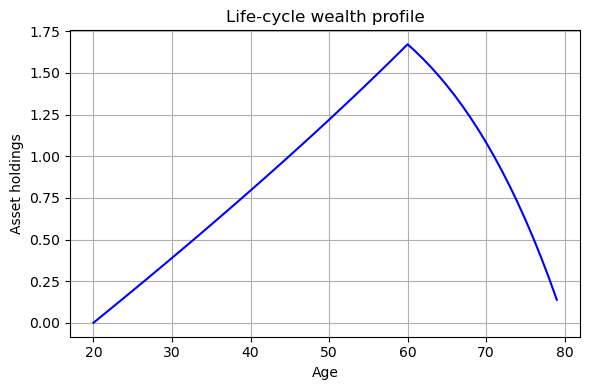

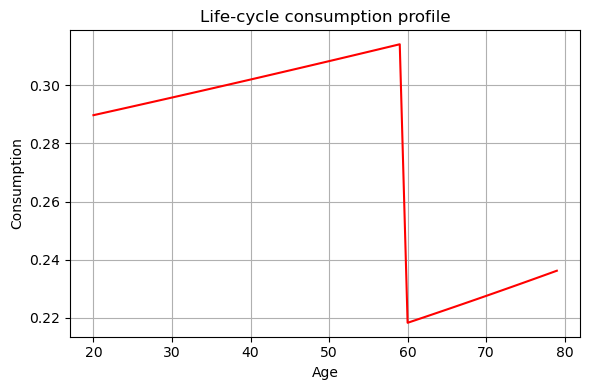

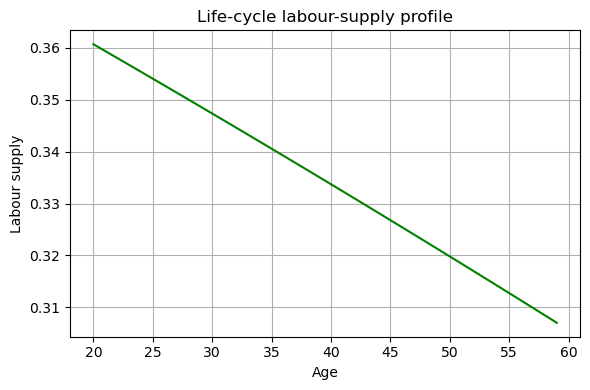

In [38]:
ages         = np.arange(20, 20 + t + tr)
ages_workers = np.arange(20, 20 + t)

# --- Wealth ---
fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(ages, aopt, 'b-', linewidth=1.5)
ax1.set_xlabel('Age'); ax1.set_ylabel('Asset holdings')
ax1.set_title('Life-cycle wealth profile'); ax1.grid(True)
plt.tight_layout()
fig1.savefig(os.path.join(output_dir, 'olg_ak60_wealth.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Consumption ---
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(ages, copt, 'r-', linewidth=1.5)
ax2.set_xlabel('Age'); ax2.set_ylabel('Consumption')
ax2.set_title('Life-cycle consumption profile'); ax2.grid(True)
plt.tight_layout()
fig2.savefig(os.path.join(output_dir, 'olg_ak60_consumption.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Labour supply ---
fig3, ax3 = plt.subplots(figsize=(6, 4))
ax3.plot(ages_workers, nopt, 'g-', linewidth=1.5)
ax3.set_xlabel('Age'); ax3.set_ylabel('Labour supply')
ax3.set_title('Life-cycle labour-supply profile'); ax3.grid(True)
plt.tight_layout()
fig3.savefig(os.path.join(output_dir, 'olg_ak60_labour.png'), dpi=150, bbox_inches='tight')
plt.show()

# Extension: steady-state uniqueness and basin of attraction

## 12. Sensitivity to initial conditions

In the AK60 economy the steady state is determined by the fixed-point system
$$K = \mathcal{S}\bigl(w(K,L),\,r(K,L),\,p(K,L)\bigr), \qquad L = \mathcal{N}(\cdot)$$
where $\mathcal{S}$ and $\mathcal{N}$ are aggregate household savings and labour supply implied by the cohort problem. **Unlike the infinite-horizon Ramsey model, this fixed-point need not be unique**: the OLG savings function is not generally monotone in $r$, because of competing income/substitution effects, the dependence of pension wealth $p$ on factor prices, and the coupling between $L$ and $K$ through wages. Galor & Ryder (1989) give sufficient conditions for uniqueness; when they fail, the system can have multiple roots, alternating stable (slope $<1$) and unstable (slope $>1$). The dampened iteration of Section 7 then converges to *whichever* stable steady state lies in the basin of attraction of $(K_0, L_0)$.

This section runs two diagnostics on our solver:

1. a **multi-start sweep** showing how convergence depends on $(K_0, L_0)$ — Section 12;
2. a **graphical fixed-point map** $K' = G(K\,|\,L^*)$ — Section 13.

### 12a. Wrapper: solve from arbitrary initial condition

In [42]:
def solve_from_initial(K0, L0, par_template,
                       nq=40, nq1=30, tol=1e-3, tolk=1e-3, phi=0.8):
    """
    Run full outer + inner solver from arbitrary (K0, L0). Silent.
    Returns dict with converged (K, L), iterations, criterion, and (K, L) path.

    Uses 'while q < nq AND krit > tol' (early stopping), unlike
    solve_steady_state which mirrors the notebook's 'or' form.
    """
    par = dict(par_template)
    t, tr = par['t'], par['tr']

    aopt = np.zeros(t+tr)
    copt = np.zeros(t+tr)
    nopt = 0.30 * np.ones(t)
    par['nopt'] = nopt

    kbar, nbar = float(K0), float(L0)
    k60_init = 0.10
    q, krit  = 0, 1.0 + tol
    path_K, path_L = [kbar], [nbar]

    while q < nq and krit > tol:
        q += 1
        w   = wage(kbar, nbar, par)
        r   = interest(kbar, nbar, par)
        pen = par['rep'] * (1.0 - par['tau']) * w * nbar * 1.5
        par.update({'w': w, 'r': r, 'pen': pen})

        with contextlib.redirect_stdout(io.StringIO()):
            aopt, copt, nopt, k60_init = shooting_loop(
                aopt, copt, nopt, par, nq1, tolk, k60_init
            )

        knew = np.mean(aopt)
        nnew = np.mean(nopt) * 2.0/3.0
        krit = abs((kbar - knew) / kbar)
        kbar = phi*kbar + (1.0-phi)*knew
        nbar = phi*nbar + (1.0-phi)*nnew
        path_K.append(kbar); path_L.append(nbar)

    return dict(K=kbar, L=nbar, iters=q, krit=krit,
                path_K=np.array(path_K), path_L=np.array(path_L))

### 12b. Multi-start sweep over $(K_0, L_0)$

Sweep takes ≈40–60 s on a 5×5 grid (every starting point runs the full nested iteration).

In [45]:
K_star, L_star = ss['kbar'], ss['nbar']

K0_grid = np.linspace(0.6*K_star, 1.4*K_star, 5)
L0_grid = np.linspace(0.7*L_star, 1.3*L_star, 5)

records = []
print(f'Reference (Section 8):  K* = {K_star:.5f},  L* = {L_star:.5f}\n')
print(f'{"K0":>8s} {"L0":>8s} {"K_conv":>10s} {"L_conv":>10s} {"|dK|":>10s} {"iter":>5s} conv?')
print('-'*65)

t_sweep = time.time()
for K0 in K0_grid:
    for L0 in L0_grid:
        out = solve_from_initial(K0, L0, par, nq=40)
        # Convergence: criterion below tol AND landed near (K*, L*)
        converged = (out['krit'] < tol) and (abs(out['K'] - K_star) < 0.05*K_star)
        records.append({**out, 'K0': K0, 'L0': L0, 'converged': converged})
        flag = 'YES' if converged else 'no '
        print(f'{K0:8.4f} {L0:8.4f} {out["K"]:10.5f} {out["L"]:10.5f} '
              f'{abs(out["K"]-K_star):10.2e} {out["iters"]:5d}  {flag}')

n_total = len(records); n_conv = sum(r['converged'] for r in records)
print(f'\n{n_conv}/{n_total} initial conditions converged to (K*, L*).  '
      f'(Sweep: {time.time()-t_sweep:.1f}s)')

Reference (Section 8):  K* = 0.87138,  L* = 0.22262

      K0       L0     K_conv     L_conv       |dK|  iter conv?
-----------------------------------------------------------------
  0.5228   0.1558    0.87139    0.22262   1.71e-05    25  YES


C:\Users\russale86005\AppData\Local\Temp\ipykernel_33500\159991356.py:7: RuntimeWarning: invalid value encountered in scalar power
  return (1.0 - par['alpha']) * k**par['alpha'] * l**(-par['alpha'])
C:\Users\russale86005\AppData\Local\Temp\ipykernel_33500\159991356.py:3: RuntimeWarning: invalid value encountered in scalar power
  return par['alpha'] * k**(par['alpha']-1.0) * l**(1.0-par['alpha']) - par['delta']


  0.5228   0.1892 -1245416209023792423245551659923981161184499181455147008.00000   -0.06415   1.25e+54    32  no 
  0.5228   0.2226 -9724466080918125442283349776532524165325530450624512.00000   -0.14050   9.72e+51    32  no 
  0.5228   0.2560 585719973177547292672.00000   -0.11911   5.86e+20    32  no 
  0.5228   0.2894 9925692813391849882867001017566001889280.00000 -28178.06766   9.93e+39    33  no 
  0.6971   0.1558    0.87144    0.22264   6.10e-05    25  YES
  0.6971   0.1892    0.87138    0.22262   3.54e-06    22  YES
  0.6971   0.2226    0.87139    0.22262   1.44e-05    15  YES
  0.6971   0.2560   17.25448   -0.39372   1.64e+01    40  no 
  0.6971   0.2894 -15688991620060002354759254789907808256.00000   -0.13283   1.57e+37    32  no 
  0.8714   0.1558    0.87145    0.22264   7.83e-05    25  YES
  0.8714   0.1892    0.87145    0.22264   7.29e-05    22  YES
  0.8714   0.2226    0.87150    0.22266   1.26e-04     1  YES
  0.8714   0.2560    0.87259    0.22298   1.21e-03    21  YES
  0

### 12c. Basin-of-attraction plot

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

K0s  = np.array([r['K0'] for r in records])
L0s  = np.array([r['L0'] for r in records])
conv = np.array([r['converged'] for r in records])

# (a) Basin of attraction
axes[0].scatter(K0s[conv],  L0s[conv],  c='#1E2761', s=140, marker='o',
                edgecolor='k', label='converged to $(K^*, L^*)$', zorder=3)
axes[0].scatter(K0s[~conv], L0s[~conv], c='#C0392B', s=140, marker='x',
                linewidths=2.5, label='did not converge', zorder=3)
axes[0].plot(K_star, L_star, '*', color='#F1C40F', markersize=24,
             markeredgecolor='k', markeredgewidth=1, label='$(K^*,L^*)$', zorder=4)
axes[0].set_xlabel('Initial $K_0$'); axes[0].set_ylabel('Initial $L_0$')
axes[0].set_title('Basin of attraction in $(K_0, L_0)$')
axes[0].legend(loc='best'); axes[0].grid(True, alpha=0.3)

# (b) Convergent trajectories
for r in records:
    if r['converged']:
        axes[1].plot(r['path_K'], r['path_L'], '-', alpha=0.6, linewidth=0.9, color='#1E2761')
        axes[1].plot(r['path_K'][0], r['path_L'][0], 'o', color='#5A6172', markersize=4)
axes[1].plot(K_star, L_star, '*', color='#F1C40F', markersize=24,
             markeredgecolor='k', markeredgewidth=1, zorder=10, label='$(K^*,L^*)$')
axes[1].set_xlabel('K'); axes[1].set_ylabel('L')
axes[1].set_title('Convergent trajectories in $(K,L)$ plane')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Sensitivity of the OLG fixed-point iteration to initial conditions',
             fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(output_dir, 'olg_ak60_basin.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. The fixed-point map $K' = G(K \mid L^*)$

Holding $L=L^*$ fixed, run the cohort problem at the prices implied by $(K, L^*)$ and record the implied aggregate $K' = \bar a$. Plotting $K'$ against $K$ alongside the $45°$ line gives a one-dimensional fixed-point picture of the model:

- **Crossings with the $45°$ line are steady states.** For our calibration we expect a single intersection.
- **Slope at the crossing** $\equiv G'(K^*)$. The raw iteration $K_{q+1} = G(K_q)$ is locally stable iff $|G'(K^*)|<1$. The *dampened* iteration $K_{q+1} = \phi K_q + (1-\phi)G(K_q)$ has effective slope $\phi + (1-\phi)G'(K^*)$, which can be inside $(-1,1)$ even when $|G'|>1$ — this is what the dampening parameter buys us.

### 13a. Compute the savings map

In [ ]:
def implied_aggregate_K(K_input, L_fixed, par_template, nq1=30, tolk=1e-3):
    """At fixed (K, L), solve the cohort problem and return aggregate savings K'."""
    par = dict(par_template)
    t, tr = par['t'], par['tr']
    aopt = np.zeros(t+tr); copt = np.zeros(t+tr); nopt = 0.30*np.ones(t)
    par['nopt'] = nopt

    w   = wage(K_input, L_fixed, par)
    r   = interest(K_input, L_fixed, par)
    pen = par['rep'] * (1.0 - par['tau']) * w * L_fixed * 1.5
    par.update({'w': w, 'r': r, 'pen': pen})

    with contextlib.redirect_stdout(io.StringIO()):
        aopt, copt, nopt, _ = shooting_loop(aopt, copt, nopt, par, nq1, tolk, 0.10)
    return np.mean(aopt)

# K range chosen so the inner shooting (warm-started at k60_init=0.10) is
# well-conditioned. Outside this range the secant on terminal wealth can
# overshoot and the household problem returns nonsense.
K_grid    = np.linspace(0.78*K_star, 1.30*K_star, 14)
K_implied = np.array([implied_aggregate_K(K, L_star, par) for K in K_grid])

# Local slope at K* (central difference on bracketing grid points)
ix = int(np.argmin(np.abs(K_grid - K_star)))
ix = max(1, min(len(K_grid)-2, ix))
slope_at_star  = (K_implied[ix+1] - K_implied[ix-1]) / (K_grid[ix+1] - K_grid[ix-1])
slope_dampened = phi + (1.0 - phi) * slope_at_star

print(f"  G'(K*)                          = {slope_at_star:+.3f}")
print(f"  Effective slope with phi={phi}:    {slope_dampened:+.3f}")
print(f"  Raw iteration: {'unstable' if abs(slope_at_star)>1 else 'stable'};  "
      f"dampened: {'unstable' if abs(slope_dampened)>1 else 'stable'}.")

### 13b. Fixed-point map plot

In [ ]:
fig, ax = plt.subplots(figsize=(7.2, 6))
ax.plot(K_grid, K_implied, 'o-', color='#1E2761', markersize=6, linewidth=1.7,
        label="$G(K\,|\,L^*)$")
ax.plot(K_grid, K_grid, '--', color='#5A6172', alpha=0.8, label='$45^\circ$ line')
ax.plot(K_star, K_star, '*', color='#C0392B', markersize=22,
        markeredgecolor='k', markeredgewidth=0.8,
        label=f"steady state  $K^*={K_star:.3f}$")

ax.annotate(
    f"$G'(K^*) \\approx {slope_at_star:.2f}\\;\\Rightarrow\\;|G'|>1$\n"
    f"raw iteration $K_{{q+1}}=G(K_q)$  is unstable\n"
    f"with damping $\\phi={phi}$:  effective slope\n"
    f"$\\phi + (1-\\phi)G'(K^*) \\approx {slope_dampened:.2f}\\;\\Rightarrow\\;$ stable",
    xy=(K_star, K_star), xytext=(0.30, 0.06), textcoords='axes fraction',
    fontsize=9.5, color='#1E2761',
    bbox=dict(boxstyle='round,pad=0.4', fc='#C8D8E8', ec='#5A6172', alpha=0.85),
    arrowprops=dict(arrowstyle='->', color='#5A6172', lw=0.8))

ax.set_xlabel('Current capital  $K$')
ax.set_ylabel("Implied aggregate  $K' = \\bar{a}(K, L^*)$")
ax.set_title("Fixed-point map  $K' = G(K \,|\, L^*)$")
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(output_dir, 'olg_ak60_savings_map.png'), dpi=150, bbox_inches='tight')
plt.show()

## 14. Reading the diagnostics

**Multi-start sweep.** Every initial condition that converges lands on the *same* $(K^*, L^*)$. The non-converged starts are not converging to a different steady state — they are diverging because the inner shooting blows up when prices are too far from equilibrium (very small $K_0$ gives implausibly high $r$). This is **empirical evidence that the steady state is unique on this calibration**. With genuinely multiple steady states we would see distinct converged values clustered into separate basins on the $(K_0,L_0)$ plane.

**Fixed-point map.** $G(K \mid L^*)$ is monotone decreasing and crosses the $45°$ line exactly once — uniqueness, confirmed graphically. The slope at the crossing, however, satisfies $|G'(K^*)| > 1$: the **un-dampened iteration $K_{q+1} = G(K_q)$ would be locally unstable**. The dampening factor $\phi = 0.8$ is not a numerical convenience — it is what turns an unstable map into a contraction with effective slope inside $(-1,1)$. Reducing $\phi$ (toward 0) speeds convergence when $|G'|<1$ but breaks down as $|G'|$ grows; raising $\phi$ (toward 1) always works but slows convergence linearly.

**When uniqueness fails.** OLG models can deliver multiple steady states whenever aggregate savings is non-monotone in $r$. Common channels:
- $\sigma > 1$ with a strong income effect of $r$ on cohort savings;
- generous PAYG pensions, since $p$ depends on $w$ and shifts cohort budgets in a price-dependent way;
- elastic labour supply, which folds the 2-D map $(K,L)\mapsto (K',L')$ back on itself.

When that happens, $G(K\,|\,L^*)$ crosses the $45°$ line at multiple points, alternating stable ($|G'|<1$) and unstable ($|G'|>1$). The dampened iteration converges to whichever stable steady state contains $(K_0, L_0)$ in its basin of attraction. The two diagnostics above are the workhorse tools for detecting multiplicity in practice: a *non-monotone* savings map, or a multi-start sweep that produces *distinct* converged values.